# PRO-cap Atlas BPNet locus viewer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kundajelab/procap-atlas/blob/main/notebooks/procap_atlas_bpnet_locus_viewer.ipynb)

This lightweight notebook visualizes one locus with fold-averaged BPNet predictions and DeepLIFT/SHAP logos. It is set up to run in Google Colab by default. Sherlock/Open OnDemand users can skip the Colab bootstrap and optionally run the environment check below.


## Colab setup

Run this cell first in Colab. It clones the repository into `/content/procap-atlas`, installs the notebook runtime dependencies, and changes the working directory to the checkout. Outside Colab, it leaves the current checkout alone.


In [1]:
from pathlib import Path
import os
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_DIR = Path("/content/procap-atlas") if IN_COLAB else Path.cwd()

if IN_COLAB:
    if not REPO_DIR.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "https://github.com/kundajelab/procap-atlas.git",
                str(REPO_DIR),
            ],
            check=True,
        )
    os.chdir(REPO_DIR)
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "bpnet-lite",
            "huggingface-hub",
            "matplotlib",
            "numpy",
            "pandas",
            "pybigtools==0.2.5",
            "pyfaidx",
            "pyyaml",
            "seaborn",
            "tangermeme",
        ],
        check=True,
    )

print(f"Running in Colab: {IN_COLAB}")
print(f"Working directory: {Path.cwd()}")


Running in Colab: False
Working directory: /Users/adamhe/github/procap-atlas/notebooks


## Optional Open OnDemand check

Sherlock Open OnDemand users can set `RUN_ONDEMAND_ENV_CHECK = True` and run this cell after selecting the `PRO-cap Atlas (uv)` kernel. Colab users should leave it disabled.


In [2]:
RUN_ONDEMAND_ENV_CHECK = False

if RUN_ONDEMAND_ENV_CHECK:
    from pathlib import Path as _Path
    import importlib.util as _importlib_util
    import os as _os
    import sys as _sys

    _numpy_spec = _importlib_util.find_spec("numpy")
    _numpy_origin = _Path(_numpy_spec.origin).resolve() if _numpy_spec else None
    _environment_root = _Path(_sys.prefix).resolve()
    print(f"Python: {_sys.executable}")
    print(f"Environment: {_environment_root}")
    print(f"NumPy candidate: {_numpy_origin}")
    print(f"PYTHONPATH: {_os.environ.get('PYTHONPATH')!r}")
    if _os.environ.get("PYTHONPATH"):
        raise RuntimeError(
            "The PRO-cap Atlas kernel did not remove the Open OnDemand PYTHONPATH. "
            "Reinstall it with notebooks/install_uv_kernel.py and restart JupyterLab."
        )
    _ondemand_paths = [
        path
        for path in _sys.path
        if path.startswith("/share/software/user/open/py-jupyterlab/")
    ]
    if _ondemand_paths:
        raise RuntimeError(
            f"Open OnDemand PYTHONPATH entries are affecting imports: {_ondemand_paths}. "
            "Reinstall the kernel with notebooks/install_uv_kernel.py."
        )
    if _numpy_origin is None or not _numpy_origin.is_relative_to(_environment_root):
        raise RuntimeError(
            "NumPy is not resolving from the selected uv environment. Reinstall the "
            "PRO-cap Atlas kernel with notebooks/install_uv_kernel.py."
        )
else:
    print("Skipping Open OnDemand environment check.")


Skipping Open OnDemand environment check.


## Import dependencies

In [3]:
from pathlib import Path
import importlib
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

for _parent in [Path.cwd(), *Path.cwd().parents]:
    if (_parent / "src").is_dir() and str(_parent) not in sys.path:
        sys.path.insert(0, str(_parent))
        break

import notebooks.locus_viewer as locus_viewer

locus_viewer = importlib.reload(locus_viewer)

from notebooks.locus_viewer import (
    best_device,
    call_and_annotate_seqlets,
    cpm_scale_for,
    deeplift_attributions,
    deeplift_attributions_batch,
    ensemble_prediction,
    ensemble_predictions,
    logo_offsets_for_region,
    plot_locus_summary,
    region_input,
    region_inputs,
    save_locus_viewer_outputs,
    setup_experiment,
)

sns.set_style("whitegrid")


/Users/adamhe/github/procap-atlas/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Choose the experiment and one 1-based region of interest. The model input is centered on this region, and the same region is used for the observed/predicted tracks and DeepLIFT logos. Set `TRACK_VALUE_CLIP` to a positive value such as `200` to cap displayed observed/predicted signal values, or `None` to show the full range. Set `SHOW_SEQLETS = True` to call seqlets and annotate them against the MEME motif file when it is available.


In [27]:
EXP_ID = "ENCSR342WAR"
REGION = "chr2:181680497-181680896"
REVERSE_COMPLEMENT = True
TRACK_VALUE_CLIP = 200
SHOW_SEQLETS = True
SEQLET_MOTIF_PATH = Path("data/JASPAR2026_CORE_vertebrates_non-redundant_pfms_meme.txt")
SEQLET_THRESHOLD = 0.05
N_FOLDS = 7
BATCH_SIZE = 8
DEVICE = best_device()  # cuda, else Apple Metal (mps), else cpu
WORK_DIR = Path(os.environ.get("SCRATCH", ".cache")) / "procap_atlas_locus_viewer"
WORK_DIR.mkdir(parents=True, exist_ok=True)
print(f"Device: {DEVICE}")
print(f"Work directory: {WORK_DIR}")


Device: mps
Work directory: .cache/procap_atlas_locus_viewer


The following helper functions will download and set up the data and model files.

In [28]:
resources = setup_experiment(EXP_ID, WORK_DIR, N_FOLDS)
chrom, region_start, region_end, center, X = region_input(resources, REGION)
logo_chrom, logo_start, logo_end, logo_offsets = logo_offsets_for_region(REGION)

# Observed/predicted coverage and counts DeepLIFT are all on a raw-count
# scale that a library's sequencing depth moves directly; this puts them
# on a common CPM footing so a track is comparable across experiments.
# Profile DeepLIFT is exempt -- see cpm_scale_for's docstring -- and is
# never scaled. None (e.g. configs/n_reads.txt missing) falls back to raw
# units with a warning rather than failing the whole cell.
cpm_scale = cpm_scale_for(EXP_ID)
print(resources["config"].get("biosample", EXP_ID), X.shape, logo_offsets,
      f"cpm_scale={cpm_scale}")


neuron torch.Size([1, 4, 2114]) (857, 1257)


## Predictions

Run each fold locally, average profile logits and log-count predictions, then convert the ensemble to count-scaled strand profiles. The observed and predicted tracks are plotted separately in the combined summary figure below so each can use its own y scale.


In [29]:
prediction = ensemble_prediction(resources, X, N_FOLDS, DEVICE)

Predicting fold 1/7 (1 region(s)): ENCSR342WAR.fold0.torch
Predicting fold 2/7 (1 region(s)): ENCSR342WAR.fold1.torch
Predicting fold 3/7 (1 region(s)): ENCSR342WAR.fold2.torch
Predicting fold 4/7 (1 region(s)): ENCSR342WAR.fold3.torch
Predicting fold 5/7 (1 region(s)): ENCSR342WAR.fold4.torch
Predicting fold 6/7 (1 region(s)): ENCSR342WAR.fold5.torch
Predicting fold 7/7 (1 region(s)): ENCSR342WAR.fold6.torch


## DeepLIFT

Compute profile-head and count-head DeepLIFT/SHAP logos using one soft reference whose A/C/G/T probabilities are the observed input-wide nucleotide frequencies.

In [30]:
attributions = deeplift_attributions(
    resources, X, logo_offsets, N_FOLDS, BATCH_SIZE, DEVICE
)


DeepLIFT fold 1/7 (1 region(s)): ENCSR342WAR.fold0.torch
DeepLIFT fold 2/7 (1 region(s)): ENCSR342WAR.fold1.torch
DeepLIFT fold 3/7 (1 region(s)): ENCSR342WAR.fold2.torch
DeepLIFT fold 4/7 (1 region(s)): ENCSR342WAR.fold3.torch
DeepLIFT fold 5/7 (1 region(s)): ENCSR342WAR.fold4.torch
DeepLIFT fold 6/7 (1 region(s)): ENCSR342WAR.fold5.torch
DeepLIFT fold 7/7 (1 region(s)): ENCSR342WAR.fold6.torch


## Seqlets

Optionally call seqlets from the displayed DeepLIFT/SHAP logo window and annotate them against a MEME motif database using tangermeme and memelite. If the motif file is absent, seqlets are still called and plotted without motif names.

In [31]:
seqlet_annotations = None
if SHOW_SEQLETS:
    seqlet_annotations = call_and_annotate_seqlets(
        attributions,
        X,
        logo_offsets,
        motif_path=SEQLET_MOTIF_PATH,
        reverse_complement=REVERSE_COMPLEMENT,
        threshold=SEQLET_THRESHOLD,
    )
    display(
        pd.concat(seqlet_annotations.values(), ignore_index=True)
        if seqlet_annotations
        else None
    )


,example_idx,start,end,attribution,p-value,head,signed_attribution,strand,score,motif_idx,motif_name,motif_pvalue
0,0,344,359,0.774241,0.008264,profile,0.677230,.,0.774241,-1,seqlet,NaN
1,0,83,96,0.385486,0.018038,profile,0.362496,.,0.385486,-1,seqlet,NaN
2,0,269,279,0.249866,0.028345,profile,0.226146,.,0.249866,-1,seqlet,NaN
3,0,150,161,0.323865,0.031571,profile,0.323865,.,0.323865,-1,seqlet,NaN
4,0,318,328,0.228979,0.041870,profile,0.177985,.,0.228979,-1,seqlet,NaN
5,0,373,385,0.363352,0.044567,profile,0.282306,.,0.363352,-1,seqlet,NaN
6,0,120,133,0.354445,0.045782,profile,0.340074,.,0.354445,-1,seqlet,NaN
7,0,82,97,0.595053,0.028992,count,0.544893,.,0.595053,-1,seqlet,NaN
8,0,11,26,0.502002,0.030853,count,0.481402,.,0.502002,-1,seqlet,NaN
9,0,71,80,0.195571,0.031760,count,0.191492,.,0.195571,-1,seqlet,NaN


## Summary figure

The observed track, predicted track, and logos are stacked in one figure to make the panels easier to compare.

(<Figure size 791.667x166.667 with 4 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='Genomic position'>],
       dtype=object))

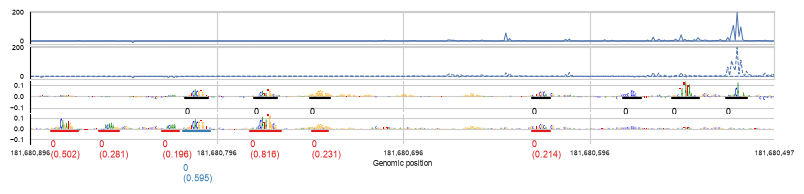

In [32]:
plot_locus_summary(
    prediction,
    attributions,
    resources,
    EXP_ID,
    REGION,
    REGION,
    REGION,
    logo_start,
    logo_end,
    REVERSE_COMPLEMENT,
    TRACK_VALUE_CLIP,
    seqlet_annotations,
)


## Optional save

Save the current figures and arrays for later inspection.


In [20]:
OUTPUT_DIR = (
    Path("plots/bpnet/locus_viewer")
    / EXP_ID
    / REGION.replace(":", "_").replace(",", "")
)
save_locus_viewer_outputs(
    OUTPUT_DIR,
    prediction,
    attributions,
    resources,
    EXP_ID,
    REGION,
    REGION,
    REGION,
    logo_start,
    logo_end,
    REVERSE_COMPLEMENT,
    TRACK_VALUE_CLIP,
    seqlet_annotations,
    cpm_scale,
)
print(f"Saved {OUTPUT_DIR}")


Saved plots/bpnet/locus_viewer/ENCSR342WAR/chr2_181680497-181680896


## Multi-region sweep

Everything above runs one region at a time. For a comparison across many
regions -- alternate TSSs of a gene, say -- use the batch helpers instead.
They make the fold model the outer loop, so all seven load **once for the
whole batch** rather than once per region: a sweep over N regions costs 7
model loads, not 7N.

`region_inputs` returns a record frame aligned row-for-row with the batch, so
predictions and attributions index the same way. All regions in one call must
be the same width, because `logo_offsets` is shared across the batch; group by
width and call once per group otherwise.

To sweep experiments as well, wrap this in a loop over `EXP_ID` and call
`setup_experiment` per experiment -- downloads are cached in `WORK_DIR`, so
only the first pass pays for them.


In [ ]:
REGIONS = [
    "chr2:181680497-181680896",
    "chr2:181681497-181681896",
]

spans = [region.split(":")[1].split("-") for region in REGIONS]
widths = {int(end) - int(start) for start, end in spans}
assert len(widths) == 1, f"all regions must share a width, got {sorted(widths)}"

records, X_batch = region_inputs(resources, REGIONS)
offsets = records.loc[0, "logo_offsets"]

predictions = ensemble_predictions(resources, X_batch, N_FOLDS, DEVICE, BATCH_SIZE)
attributions_batch = deeplift_attributions_batch(
    resources, X_batch, offsets, N_FOLDS, BATCH_SIZE, DEVICE
)

records["predicted_total"] = predictions.reshape(len(records), -1).sum(axis=1)
print(predictions.shape, {k: v.shape for k, v in attributions_batch.items()})
records[["region", "chrom", "start", "end", "predicted_total"]]
